<a href="https://colab.research.google.com/github/thaovu31251021311-star/Project_Vietnamese-Banknotes/blob/main/Money.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization,Activation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ==============================
# KHAI BÁO THÔNG SỐ
# ==============================

img_height, img_width = 128, 128
batch_size = 32

# ==============================
# DATA AUGMENTATION CHO TRAIN
# ==============================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

# ==============================
# VALIDATION / TEST
# KHÔNG AUGMENTATION
# ==============================

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [2]:
from keras.layers import GlobalAveragePooling2D

# ==============================
# LOAD TRAIN DATA
# ==============================

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Datasets_Money/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

# ==============================
# LOAD VALIDATION DATA
# ==============================

validation_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Datasets_Money/val",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

# ==============================
# BUILD CNN MODEL
# ==============================

model = Sequential([
    Conv2D(
        32,
        (3,3),
        padding='same',
        input_shape=(img_height, img_width, 3)
    ),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(2,2),

    # QUAN TRỌNG
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(
        train_generator.num_classes,
        activation="softmax"
    )
])

# XEM KIẾN TRÚC MODEL
model.summary()

Found 1800 images belonging to 9 classes.
Found 270 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,817 (436.79 KB)

 Trainable params: 111,369 (435.04 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1174s 21s/step - accuracy: 0.2289 - loss: 2.0732 - val_accuracy: 0.1185 - val_loss: 2.2516 - learning_rate: 0.0010
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.3383 - loss: 1.8184 - val_accuracy: 0.1111 - val_loss: 2.3654 - learning_rate: 0.0010
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.3944 - loss: 1.6379 - val_accuracy: 0.1370 - val_loss: 2.4058 - learning_rate: 0.0010
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4187 - loss: 1.6122
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
57/57 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.4222 - loss: 1.5764 - val_accuracy: 0.1704 - val_loss: 2.4978 - learning_rate: 0.0010
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.4867 - loss: 1.4296 - val_accuracy: 0.1593 - val_loss: 2.3520 - learning_rate: 5.0000e-04
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.5144 - loss: 1.3545 

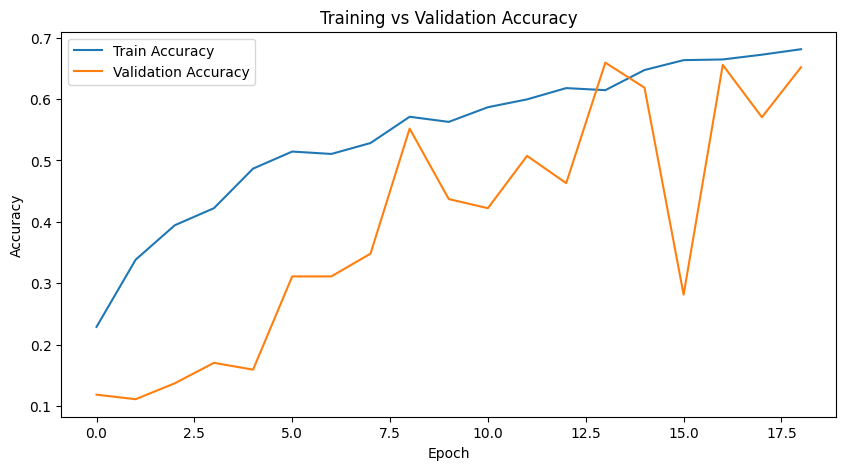

In [3]:
# ==============================
# COMPILE MODEL
# ==============================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==============================
# EARLY STOPPING
# ==============================

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# ==============================
# GIẢM LEARNING RATE
# ==============================

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# ==============================
# TRAIN MODEL
# ==============================

epochs = 100
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

# ==============================
# LOAD TEST DATA
# ==============================

test_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Datasets_Money/test",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# TEST MODEL
# ==============================

loss, acc = model.evaluate(test_generator)
print("\nTest accuracy:", acc)

# ==============================
# VẼ BIỂU ĐỒ
# ==============================

plt.figure(figsize=(10,5))

# TRAIN ACCURACY
plt.plot(
    history.history['accuracy'],
    label="Train Accuracy"
)

# VALIDATION ACCURACY
plt.plot(
    history.history['val_accuracy'],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [4]:
model.save("training_model_money.keras")

Saving z7871104906531_18687757aa08d3faa87508d9a0b7519b.jpg to z7871104906531_18687757aa08d3faa87508d9a0b7519b (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


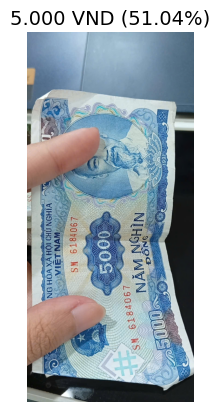

In [21]:
from keras.models import load_model
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = load_model("training_model_money.keras")

# Danh sách class
classes = list(train_generator.class_indices.keys())

# Upload ảnh
uploaded = files.upload()

# Lấy tên file
img_path = list(uploaded.keys())[0]

# Đọc ảnh
img = cv2.imread(img_path)

# Chuyển BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize đúng kích thước model
img_resize = cv2.resize(img_rgb, (img_width, img_height))

# Normalize
img_resize = img_resize.astype('float32') / 255.0

# Thêm batch dimension
img_input = np.expand_dims(img_resize, axis=0)

# Predict
prediction = model.predict(img_input)

# Lấy class có xác suất cao nhất
predicted_class = np.argmax(prediction)

# Độ chính xác
confidence = np.max(prediction) * 100

# Hiển thị ảnh
plt.imshow(img_rgb)
plt.axis('off')

# Hiển thị kết quả lên title
plt.title(
    f"{classes[predicted_class]} ({confidence:.2f}%)",
    fontsize=14
)

plt.show()